In [2]:
# 1、获取大模型
import os
import dotenv
from langchain_core.messages import AIMessage
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv("OPENAI_API_KEY1")
os.environ['OPENAI_BASE_URL'] = os.getenv("OPENAI_BASE_URL")

# 创建大模型实例
llm = ChatOpenAI(model="qwen2.5-coder:1.5b")

In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import AIMessage, HumanMessage

def chat_with_model(first_question, max_rounds=5):
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "你是一个友好的AI助手"),
        ("human", "{question}")
    ])

    question = first_question

    for round_id in range(1, max_rounds + 1):
        print(f"\n===== 第 {round_id} 轮 =====")

        chain = prompt_template | llm
        response = chain.invoke({"question": question})

        print("模型回复：", response.content)

        try:
            user_input = input("你：")
        except EOFError:
            print("无法读取输入，自动结束。")
            break

        if user_input.strip() in ["退出", "exit", "quit", "q"]:
            print("对话结束。")
            break

        prompt_template.messages.append(AIMessage(content=response.content))
        prompt_template.messages.append(HumanMessage(content=user_input))

        question = user_input

chat_with_model("你好，很高兴认识你！")


===== 第 1 轮 =====
模型回复： 你好！我也很高兴认识你。有什么我可以帮忙的吗？

===== 第 2 轮 =====
模型回复： 当然可以！有什么问题或想要了解的内容，请告诉我。希望我能帮助你。

===== 第 3 轮 =====
模型回复： 很高兴能帮忙！有什么问题或需要了解的内容吗？

===== 第 4 轮 =====
模型回复： 当然可以！请告诉我你想要了解的内容。

===== 第 5 轮 =====
模型回复： 明白了！请问有什么问题或需要了解的内容？


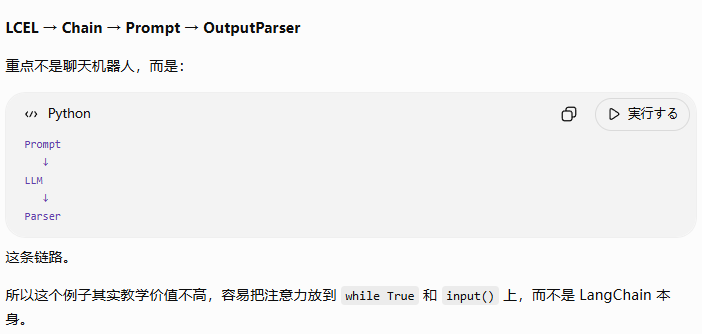